In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dataset_1 = pd.read_csv('./TrafficLabelling/Wednesday-workingHours.pcap_ISCX.csv')
dataset_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692703 entries, 0 to 692702
Data columns (total 85 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Flow ID                       692703 non-null  object 
 1    Source IP                    692703 non-null  object 
 2    Source Port                  692703 non-null  int64  
 3    Destination IP               692703 non-null  object 
 4    Destination Port             692703 non-null  int64  
 5    Protocol                     692703 non-null  int64  
 6    Timestamp                    692703 non-null  object 
 7    Flow Duration                692703 non-null  int64  
 8    Total Fwd Packets            692703 non-null  int64  
 9    Total Backward Packets       692703 non-null  int64  
 10  Total Length of Fwd Packets   692703 non-null  int64  
 11   Total Length of Bwd Packets  692703 non-null  float64
 12   Fwd Packet Length Max        692703 non-nul

In [2]:
dataset_1.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.14-209.48.71.168-49459-80-6,192.168.10.14,49459,209.48.71.168,80,6,5/7/2017 8:42,38308,1,1,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,192.168.10.3-192.168.10.17-389-49453-6,192.168.10.17,49453,192.168.10.3,389,6,5/7/2017 8:42,479,11,5,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,192.168.10.3-192.168.10.17-88-46124-6,192.168.10.17,46124,192.168.10.3,88,6,5/7/2017 8:42,1095,10,6,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,192.168.10.3-192.168.10.17-389-49454-6,192.168.10.17,49454,192.168.10.3,389,6,5/7/2017 8:42,15206,17,12,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,192.168.10.3-192.168.10.17-88-46126-6,192.168.10.17,46126,192.168.10.3,88,6,5/7/2017 8:42,1092,9,6,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [3]:
dataset_1.describe()

/Users/briancolclough/Documents/Coding/Applied-machine-learning/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/briancolclough/Documents/Coding/Applied-machine-learning/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,692703.000000,692703.000000,692703.000000,6.927030e+05,692703.000000,692703.000000,6.927030e+05,6.927030e+05,692703.000000,692703.000000,...,692703.000000,692703.000000,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05,6.927030e+05
mean,42583.995907,5686.869462,9.219523,2.800168e+07,9.556261,10.214079,5.550930e+02,1.699644e+04,233.593936,15.022183,...,6.121279,26.761141,9.224478e+04,4.760852e+04,1.627363e+05,6.315186e+04,2.211122e+07,4.743744e+05,2.252174e+07,2.173373e+07
std,19535.697710,15727.423560,5.009796,4.276680e+07,747.197814,984.204633,6.163663e+03,2.241175e+06,603.751856,51.068835,...,715.155068,6.322368,7.007049e+05,4.742081e+05,1.094616e+06,6.051023e+05,3.812415e+07,4.488512e+06,3.848292e+07,3.807725e+07
min,0.000000,0.000000,0.000000,-1.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,-1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,36235.000000,53.000000,6.000000,2.010000e+02,2.000000,1.000000,1.200000e+01,0.000000e+00,6.000000,0.000000,...,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,49822.000000,80.000000,6.000000,6.143700e+04,2.000000,2.000000,8.200000e+01,1.880000e+02,46.000000,0.000000,...,1.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,56892.000000,443.000000,17.000000,8.302437e+07,7.000000,6.000000,3.650000e+02,1.159500e+04,341.000000,32.000000,...,2.000000,32.000000,9.910000e+02,0.000000e+00,9.910000e+02,9.880000e+02,1.590000e+07,0.000000e+00,1.650000e+07,1.000000e+07
max,65535.000000,65487.000000,17.000000,1.200000e+08,203943.000000,272353.000000,1.224076e+06,6.270000e+08,24820.000000,2065.000000,...,197124.000000,60.000000,1.000000e+08,7.420000e+07,1.050000e+08,1.000000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


## Question 3

I chose Random Forest Classifier because this is a binary classification problem with 85 features, many of which are likely correlated. Random Forest handles feature correlation well through random feature selection at each split, reducing multicollinearity issues without requiring manual feature engineering. Additionally, it's robust to class imbalance and can capture the complex, non-linear patterns typical in network intrusion data.

In [4]:
# trim the column names to remove whitespace
dataset_1.columns = dataset_1.columns.str.strip()


In [5]:
# print feature names
print(dataset_1.columns)


Index(['Flow ID', 'Source IP', 'Source Port', 'Destination IP',
       'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration',
       'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
  

## Question 4

Process the class feature/category as binary classes for supervised learning,
assign BENIGN to value 0 and the rest to value 1. Check its balance for the Dataset 1

In [6]:
# map the label column to binary classes
dataset_1['Label'] = dataset_1['Label'].map({'BENIGN': 0}).fillna(1).astype(int)


dataset_1.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.14-209.48.71.168-49459-80-6,192.168.10.14,49459,209.48.71.168,80,6,5/7/2017 8:42,38308,1,1,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,192.168.10.3-192.168.10.17-389-49453-6,192.168.10.17,49453,192.168.10.3,389,6,5/7/2017 8:42,479,11,5,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,192.168.10.3-192.168.10.17-88-46124-6,192.168.10.17,46124,192.168.10.3,88,6,5/7/2017 8:42,1095,10,6,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,192.168.10.3-192.168.10.17-389-49454-6,192.168.10.17,49454,192.168.10.3,389,6,5/7/2017 8:42,15206,17,12,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,192.168.10.3-192.168.10.17-88-46126-6,192.168.10.17,46126,192.168.10.3,88,6,5/7/2017 8:42,1092,9,6,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [7]:
# show some random rows
dataset_1.sample(5)

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
680590,192.168.10.3-192.168.10.9-53-52859-17,192.168.10.9,52859,192.168.10.3,53,17,5/7/2017 2:39,86731,2,2,...,32,0.00000,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,0
395170,192.168.10.3-192.168.10.8-53-60279-17,192.168.10.8,60279,192.168.10.3,53,17,5/7/2017 12:48,73163,2,2,...,32,0.00000,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,0
362363,192.168.10.12-192.99.239.194-41348-443-6,192.99.239.194,443,192.168.10.12,41348,6,5/7/2017 12:36,191,3,1,...,32,0.00000,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,0
355162,172.217.10.98-192.168.10.17-443-36056-6,192.168.10.17,36056,172.217.10.98,443,6,5/7/2017 12:02,115570526,23,20,...,32,53590.72727,55152.28941,219881.0,36839.0,10000000.0,4676.659647,10000000.0,9996999.0,0
22896,192.168.10.3-192.168.10.8-53-61454-17,192.168.10.8,61454,192.168.10.3,53,17,5/7/2017 9:28,61519,2,2,...,20,0.00000,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,0


In [8]:
# show the balance of the classes
print(dataset_1['Label'].value_counts())

Label
0    440031
1    252672
Name: count, dtype: int64


## Question 5

Explore Dataset 1 features with respect to the class. (Hint: features Source Port
and Destination Port are very useful; research and find out important networking port
numbers and one-hot-encode them. Unimportant port numbers or source port numbers can
be assigned to a feature called 'other ports'.)

In [9]:
def log_port_data(dataset):
    # sum the unique values
    source_port_values = dataset["Source Port"].value_counts()
    destination_port_values = dataset["Destination Port"].value_counts()

    #print the most common 10 values
    print('most common 10 values')
    print(source_port_values.head(15))
    print("="*75)
    print(destination_port_values.head(15))

    # print the least common 10 values
    print('\nleast common 10 values')
    print(source_port_values.tail(15))
    print("="*75)
    print(destination_port_values.tail(15))

In [10]:
attack_data = dataset_1[dataset_1['Label'] == 1]
benign_data = dataset_1[dataset_1['Label'] == 0]

print('attack data')
log_port_data(attack_data)
print('\nbenign data')
log_port_data(benign_data)

attack data
most common 10 values
Source Port
54350    30
54378    29
54454    29
54100    29
54424    28
53932    28
53890    28
53852    28
53816    28
54416    28
54392    28
53856    28
54222    28
54420    28
54140    28
Name: count, dtype: int64
Destination Port
80     252661
444        11
Name: count, dtype: int64

least common 10 values
Source Port
37352    11
35114    11
51670    10
46460    10
51662     9
39750     3
39752     3
39754     3
39748     3
39756     3
39758     3
39760     3
49633     2
49631     2
39780     1
Name: count, dtype: int64
Destination Port
80     252661
444        11
Name: count, dtype: int64

benign data
most common 10 values
Source Port
443      52110
80       24206
123       4293
137       1473
22        1011
21         603
0          330
138        326
139        166
5353       148
389        120
53         109
44826      107
37082      106
49666       78
Name: count, dtype: int64
Destination Port
53      195531
443     100229
80       48761
123 

In [11]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted

class PortEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, important_ports, port_columns):
        self.important_ports = important_ports
        self.port_columns = port_columns

    def fit(self, X, y=None):
        X = self._validate_input(X)
        self.feature_names_in_ = X.columns.tolist()

        self.output_features_ = [
            col for col in self.feature_names_in_
            if col not in self.port_columns
        ]
        for col in self.port_columns:
            base = col.strip()
            self.output_features_.extend(
                [f'{base}_port_{port}' for port in self.important_ports]
            )
            self.output_features_.append(f'{base}_port_other')
        return self

    def transform(self, X):
        check_is_fitted(self, 'feature_names_in_')
        X = self._validate_input(X).copy()

        encoded = X.drop(columns=self.port_columns)
        for col in self.port_columns:
            base = col.strip()
            for port in self.important_ports:
                encoded[f'{base}_port_{port}'] = (X[col] == port).astype(int)
            encoded[f'{base}_port_other'] = (~X[col].isin(self.important_ports)).astype(int)

        return encoded[self.output_features_]

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, 'output_features_')
        return self.output_features_

    @staticmethod
    def _validate_input(X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("PortEncoder expects a pandas DataFrame.")
        return X

In [12]:
from sklearn.pipeline import FunctionTransformer, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

important_ports = [443, 80, 123, 137, 22, 21, 0, 138, 139, 5353, 389, 53]
port_columns = ['Source Port', 'Destination Port']
drop_columns = ['Flow ID', 'Source IP', 'Destination IP']

clf = Pipeline(steps=[
    ('port_encoder', PortEncoder(important_ports, port_columns)),
    ('dropper', FunctionTransformer(lambda X: X.drop(columns=drop_columns), validate=False)),

])

encoded_dataset_1 = clf.fit_transform(dataset_1)
encoded_dataset_1.head()


,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,Destination Port_port_137,Destination Port_port_22,Destination Port_port_21,Destination Port_port_0,Destination Port_port_138,Destination Port_port_139,Destination Port_port_5353,Destination Port_port_389,Destination Port_port_53,Destination Port_port_other
0,6,5/7/2017 8:42,38308,1,1,6,6.0,6,6,6.000000,...,0,0,0,0,0,0,0,0,0,0
1,6,5/7/2017 8:42,479,11,5,172,326.0,79,0,15.636364,...,0,0,0,0,0,0,0,1,0,0
2,6,5/7/2017 8:42,1095,10,6,3150,3150.0,1575,0,315.000000,...,0,0,0,0,0,0,0,0,0,1
3,6,5/7/2017 8:42,15206,17,12,3452,6660.0,1313,0,203.058823,...,0,0,0,0,0,0,0,1,0,0
4,6,5/7/2017 8:42,1092,9,6,3150,3152.0,1575,0,350.000000,...,0,0,0,0,0,0,0,0,0,1


## Question 6

Display some histograms and anything you deem fit to pick independent Dataset 1
features. (Hint: source/destination bytes, packets, ports and the duration features.)

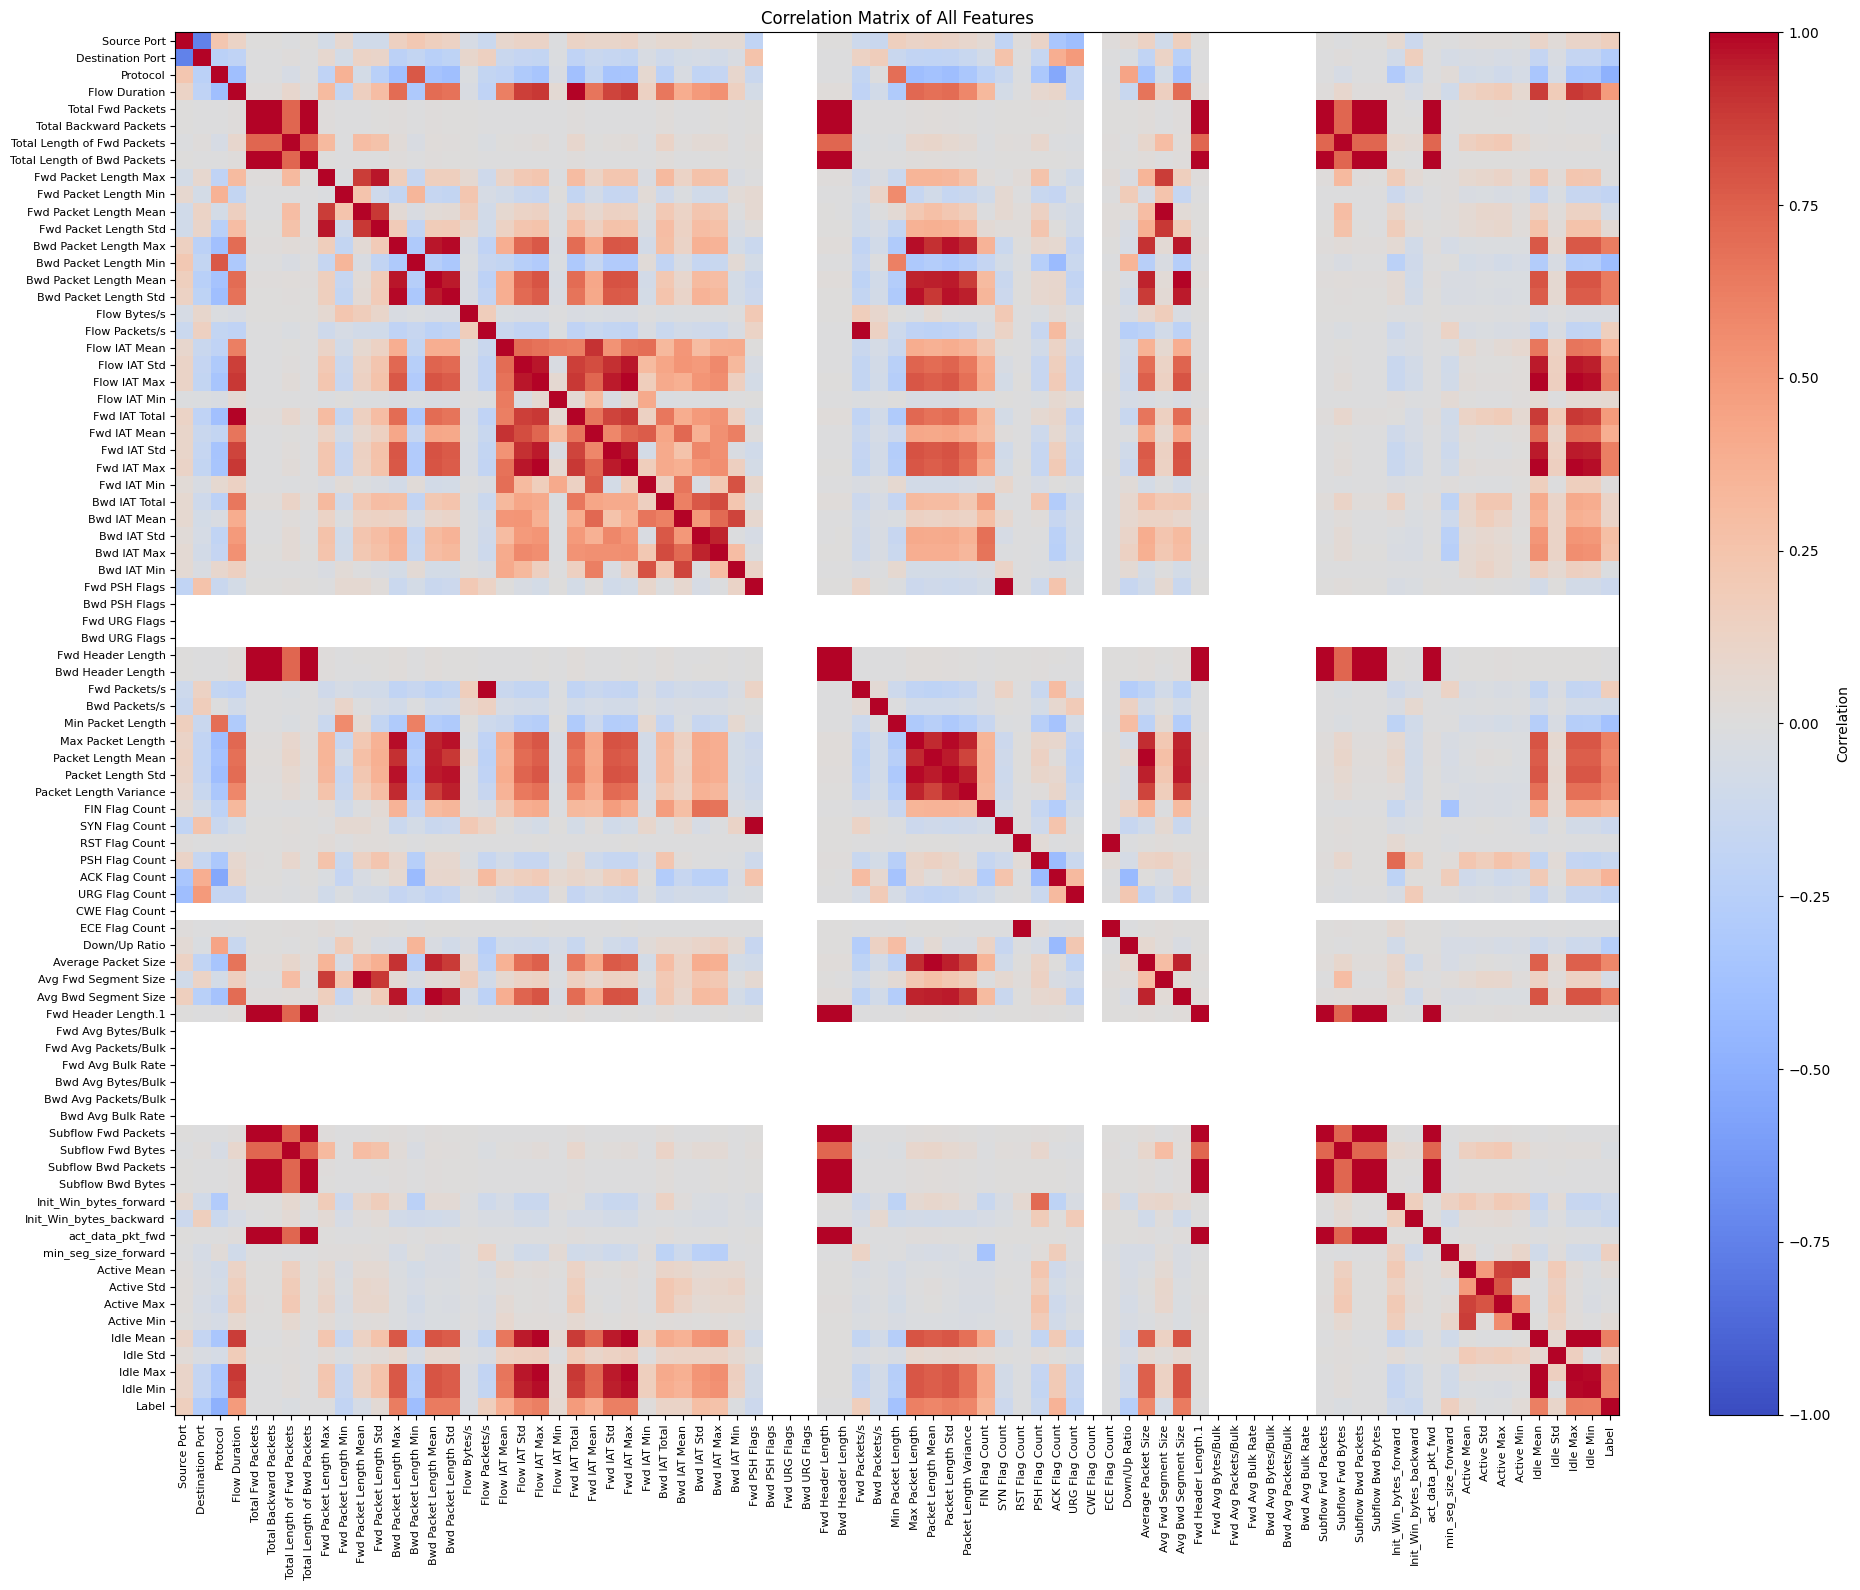

In [13]:
# Get all numeric columns from the dataset
numeric_columns = dataset_1.select_dtypes(include=[np.number]).columns.tolist()

# Calculate correlation matrix for all numeric features
correlation_matrix = dataset_1[numeric_columns].corr()

# Plot correlation heatmap
plt.figure(figsize=(20, 16))
plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(numeric_columns)), numeric_columns, rotation=90, fontsize=8)
plt.yticks(range(len(numeric_columns)), numeric_columns, fontsize=8)
plt.title('Correlation Matrix of All Features')
plt.tight_layout()
plt.show()

# Print correlation of all features with the target, if present
if ' Label' in correlation_matrix.columns:
    print("Correlation with Label (target):")
    print(correlation_matrix[' Label'].sort_values(ascending=False))




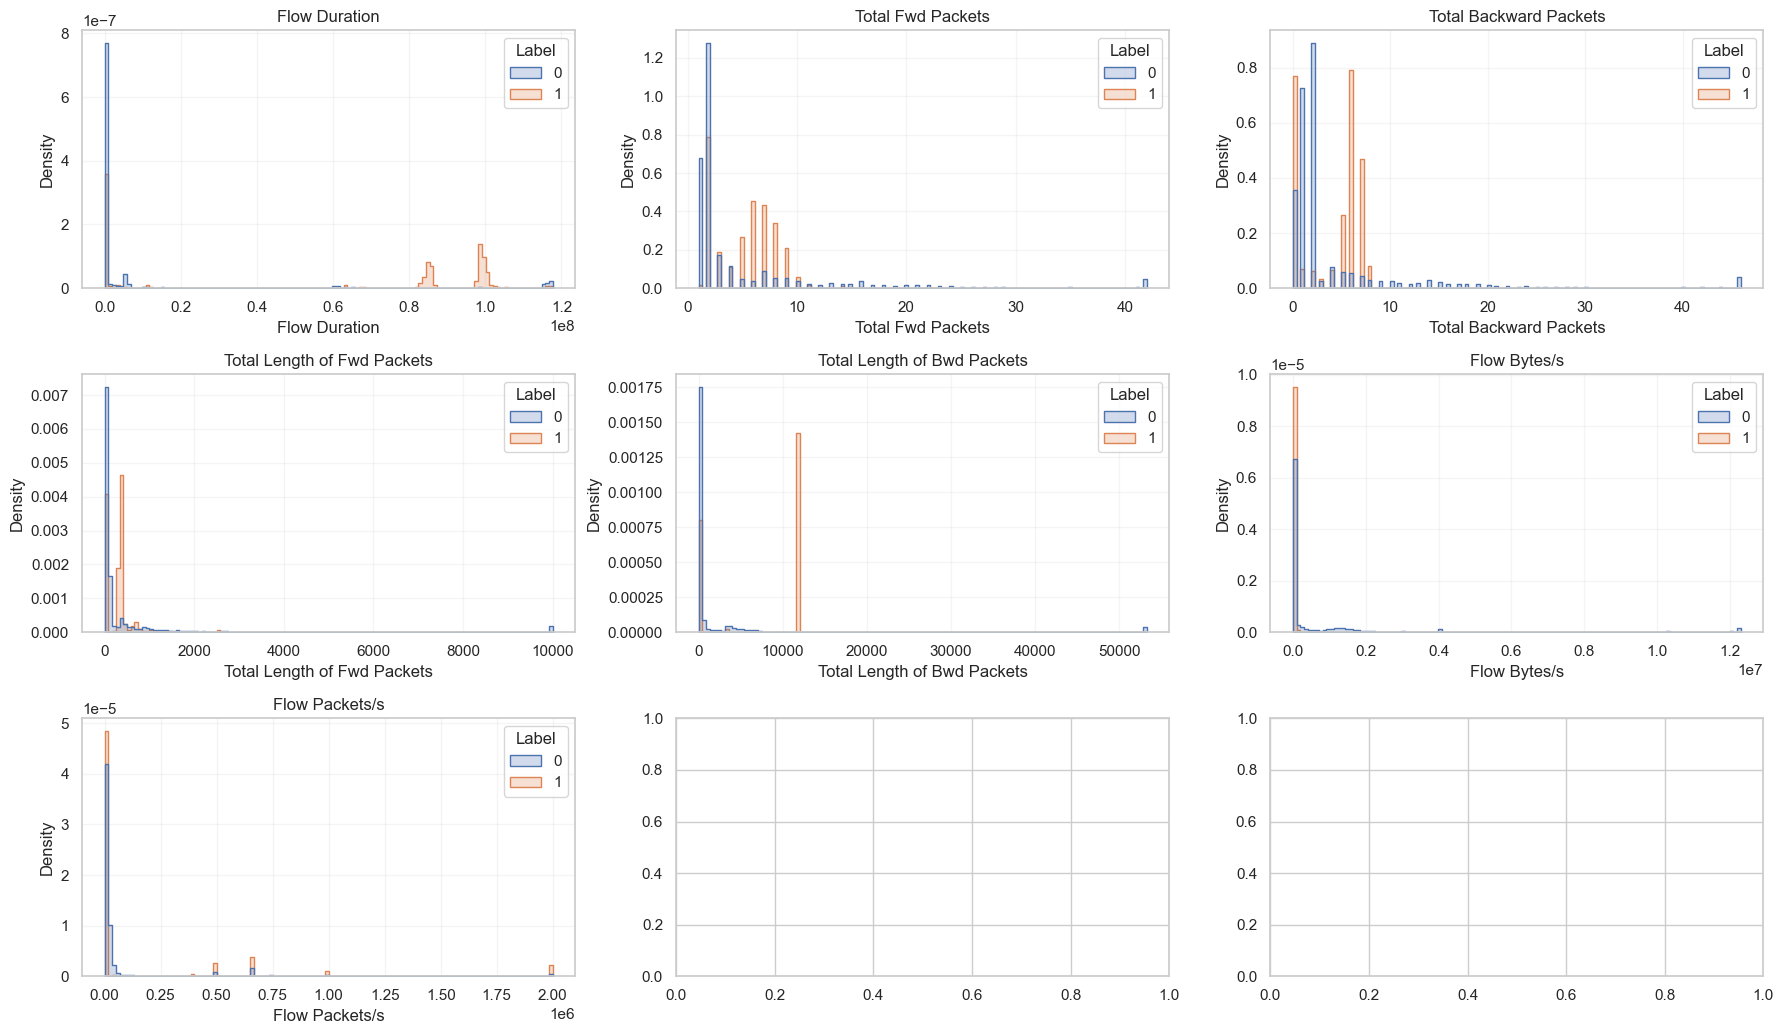

In [14]:
import math
import seaborn as sns

sns.set_theme(style="whitegrid")


def plot_histograms_by_label(df: pd.DataFrame, features, label_col: str = 'Label', bins: int = 100,
                              clip_quantiles=(0.01, 0.99)) -> None:
    num_features = len(features)
    num_cols = 3
    num_rows = math.ceil(num_features / num_cols)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 3.5 * num_rows))
    axes = axes.ravel()

    for ax, feature in zip(axes, features):
        s = df[feature].replace([np.inf, -np.inf], np.nan).dropna()
        if clip_quantiles is not None:
            lo, hi = s.quantile(clip_quantiles)
            s = s.clip(lo, hi)
        tmp = pd.DataFrame({feature: s})
        tmp[label_col] = df.loc[s.index, label_col].values
        sns.histplot(
            data=tmp,
            x=feature,
            hue=label_col,
            bins=bins,
            stat='density',
            common_norm=False,
            element='step',
            ax=ax
        )
        ax.set_title(feature)
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()


features_to_plot = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Flow Bytes/s',
    'Flow Packets/s'
]

plot_histograms_by_label(
    dataset_1,
    features_to_plot,
    bins=120,
)


Lets remove some features that are highly coorelated

In [15]:
columns_to_drop = ['Total Backward Packets', 'Bwd Packets/s', 'Total Length of Bwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Std', 'Fwd Header Length', 'Max Packet Length', 'Min Packet Length', 'Packet Length Std', "Timestamp", 'Flow ID', 'Source IP', 'Destination IP', 'Active Std', 'Active Max',	'Active Min', 'Idle Std', 'Idle Max', 'Idle Min']


In [16]:
encoded_dataset_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692703 entries, 0 to 692702
Columns: 106 entries, Protocol to Destination Port_port_other
dtypes: float64(37), int64(68), object(1)
memory usage: 560.2+ MB


## Question 7


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_validate, StratifiedShuffleSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# smaller sample size for testing on my local machine
cv_sample_size = 120_000
_df = dataset_1

sss = StratifiedShuffleSplit(n_splits=1, train_size=cv_sample_size, random_state=28)
idx, _ = next(sss.split(_df, _df['Label']))
_df = _df.iloc[idx].copy()

X_cv = _df.drop(columns=['Label'])
_y_cv = _df['Label']

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=28)
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Base preprocessing shared by all models
base_pipeline = [
    ('port_encoder', PortEncoder(important_ports, port_columns)),
    ('dropper', FunctionTransformer(lambda X: X.drop(columns=columns_to_drop), validate=False)),
    ('clean_inf', FunctionTransformer(lambda X: X.replace([np.inf, -np.inf], np.nan), validate=False)),
    ('imputer', SimpleImputer(strategy='median')),
]

rf_pipeline = Pipeline(steps=base_pipeline + [
    ('model', RandomForestClassifier(n_estimators=100, random_state=28, n_jobs=-1))
])

lr_pipeline = Pipeline(steps=base_pipeline + [
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, solver='lbfgs'))
])

knn_pipeline = Pipeline(steps=base_pipeline + [
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=25))
])


def evaluate_classifier(name, pipeline, X_cv, _y_cv, cv):
    scores = cross_validate(pipeline, X_cv, _y_cv, cv=cv, scoring=scoring, n_jobs=-1, error_score='raise')
    print(f"\n{name}")
    for metric, _ in scoring.items():
        mean = scores[f'test_{metric}'].mean()
        std = scores[f'test_{metric}'].std()
        print(f" - {metric}: {mean:.4f} {chr(177)} {std:.4f}")


evaluate_classifier('RandomForest', rf_pipeline, X_cv, _y_cv, cv)
evaluate_classifier('LogisticRegression', lr_pipeline, X_cv, _y_cv, cv)
evaluate_classifier('KNN', knn_pipeline, X_cv, _y_cv, cv)



RandomForest
 - accuracy: 0.9994 ± 0.0002
 - precision: 0.9991 ± 0.0006
 - recall: 0.9992 ± 0.0005
 - f1: 0.9991 ± 0.0003
 - roc_auc: 1.0000 ± 0.0000

LogisticRegression
 - accuracy: 0.9916 ± 0.0010
 - precision: 0.9900 ± 0.0017
 - recall: 0.9869 ± 0.0019
 - f1: 0.9885 ± 0.0013
 - roc_auc: 0.9996 ± 0.0001

KNN
 - accuracy: 0.9974 ± 0.0003
 - precision: 0.9947 ± 0.0010
 - recall: 0.9983 ± 0.0008
 - f1: 0.9965 ± 0.0004
 - roc_auc: 0.9999 ± 0.0001


 the model just seems too accurate so I'm gonna test it using only a few features to see if those features are the ones that provide enough signal

In [18]:
from sklearn.model_selection import cross_val_score

minimal_feature_pipeline = Pipeline(steps=[
    ('keep_ports', FunctionTransformer(lambda X: X[['Source Port', 'Destination Port', 'Protocol']], validate=False)),
    ('port_encoder', PortEncoder(important_ports, port_columns)),
    ('model', RandomForestClassifier(n_estimators=100, random_state=28, n_jobs=-1))
])

port_only_scores = cross_validate(minimal_feature_pipeline, X_cv, _y_cv, cv=cv, scoring={'accuracy': 'accuracy'}, n_jobs=-1)
print(f"Port-only baseline accuracy (10-fold): {port_only_scores['test_accuracy'].mean():.4f} ± {port_only_scores['test_accuracy'].std():.4f}")

Port-only baseline accuracy (10-fold): 0.9290 ± 0.0029


The port-only baseline shows that a small subset of features can achieve high accuracy. Below, I'll experiment with different feature combinations to identify the minimal set needed to come close to the performance of the full 80+ feature model.

In [19]:

minimal_feature_pipeline = Pipeline(steps=[
    ('keep_ports', FunctionTransformer(lambda X: X[['Source Port', 'Destination Port', 'Protocol', 'Total Fwd Packets', 'Flow Duration', 'Flow Bytes/s', 'Flow Packets/s']], validate=False)),
    ('port_encoder', PortEncoder(important_ports, port_columns)),
    ('clean_inf', FunctionTransformer(lambda X: X.replace([np.inf, -np.inf], np.nan), validate=False)),
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(n_estimators=100, random_state=28, n_jobs=-1))
])

minimal_feature_scores = cross_validate(minimal_feature_pipeline, X_cv, _y_cv, cv=cv, scoring={'accuracy': 'accuracy'}, n_jobs=-1)
print(f"minimal feature baseline accuracy (10-fold): {minimal_feature_scores['test_accuracy'].mean():.4f} ± {minimal_feature_scores['test_accuracy'].std():.4f}")

minimal feature baseline accuracy (10-fold): 0.9971 ± 0.0006


 instead of selecting which features to drop, I'm just gonna select which features to keep and drop everything else since with minimal features, we can gain almost all of the accuracy

In [20]:
features_to_keep=['Source Port', 'Destination Port', 'Protocol', 'Total Fwd Packets', 'Flow Duration', 'Flow Bytes/s', 'Flow Packets/s']

In [21]:
dataset_2 = pd.read_csv('./TrafficLabelling/Monday-workingHours.pcap_ISCX.csv')
dataset_3 = pd.read_csv('./TrafficLabelling/Tuesday-workingHours.pcap_ISCX.csv')
dataset_4 = pd.read_csv('./TrafficLabelling/Thursday-workingHours-Morning-WebAttacks.pcap_ISCX.csv')
dataset_5 = pd.read_csv('./TrafficLabelling/Thursday-workingHours-Afternoon-Infilteration.pcap_ISCX.csv')
dataset_6 = pd.read_csv('./TrafficLabelling/Friday-workingHours-Morning.pcap_ISCX.csv')
dataset_7 = pd.read_csv('./TrafficLabelling/Friday-workingHours-Afternoon-PortScan.pcap_ISCX.csv')
dataset_8 = pd.read_csv('./TrafficLabelling/Friday-workingHours-Afternoon-DDos.pcap_ISCX.csv')




/var/folders/ph/z5q8ly_d4312fwfnzm3ks12c0000gn/T/ipykernel_98043/2027479434.py:3: DtypeWarning: Columns (0,1,3,6,84) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset_4 = pd.read_csv('./TrafficLabelling/Thursday-workingHours-Morning-WebAttacks.pcap_ISCX.csv')


In [22]:
dataset_6.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.3-192.168.10.50-3268-56108-6,192.168.10.50,56108,192.168.10.3,3268,6,7/7/2017 8:59,112740690,32,16,...,32,3.594286e+02,1.199802e+01,380.0,343.0,16100000.0,4.988048e+05,16400000.0,15400000.0,BENIGN
1,192.168.10.3-192.168.10.50-389-42144-6,192.168.10.50,42144,192.168.10.3,389,6,7/7/2017 8:59,112740560,32,16,...,32,3.202857e+02,1.574499e+01,330.0,285.0,16100000.0,4.987937e+05,16400000.0,15400000.0,BENIGN
2,8.0.6.4-8.6.0.1-0-0-0,8.6.0.1,0,8.0.6.4,0,0,7/7/2017 9:00,113757377,545,0,...,0,9.361829e+06,7.324646e+06,18900000.0,19.0,12200000.0,6.935824e+06,20800000.0,5504997.0,BENIGN
3,192.168.10.9-224.0.0.252-63210-5355-17,192.168.10.9,63210,224.0.0.252,5355,17,7/7/2017 9:00,100126,22,0,...,32,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,BENIGN
4,192.168.10.9-224.0.0.22-0-0-0,192.168.10.9,0,224.0.0.22,0,0,7/7/2017 9:00,54760,4,0,...,0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,BENIGN


In [23]:
dataset_3.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.3-192.168.10.5-88-49182-6,192.168.10.5,49182,192.168.10.3,88,6,4/7/2017 8:54,640,7,4,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,192.168.10.3-192.168.10.5-88-49183-6,192.168.10.5,49183,192.168.10.3,88,6,4/7/2017 8:54,900,9,4,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,192.168.10.3-192.168.10.5-88-49184-6,192.168.10.5,49184,192.168.10.3,88,6,4/7/2017 8:54,1205,7,4,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,192.168.10.3-192.168.10.5-88-49185-6,192.168.10.5,49185,192.168.10.3,88,6,4/7/2017 8:54,511,7,4,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,192.168.10.3-192.168.10.5-88-49186-6,192.168.10.5,49186,192.168.10.3,88,6,4/7/2017 8:54,773,9,4,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [24]:
dataset_4.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.3-192.168.10.50-389-33898-6,192.168.10.50,33898.0,192.168.10.3,389.0,6.0,6/7/2017 8:59,113095465.0,48.0,24.0,...,32.0,203985.500,5.758373e+05,1629110.0,379.0,13800000.0,4.277541e+06,16500000.0,6737603.0,BENIGN
1,192.168.10.3-192.168.10.50-389-33904-6,192.168.10.50,33904.0,192.168.10.3,389.0,6.0,6/7/2017 8:59,113473706.0,68.0,40.0,...,32.0,178326.875,5.034269e+05,1424245.0,325.0,13800000.0,4.229413e+06,16500000.0,6945512.0,BENIGN
2,8.0.6.4-8.6.0.1-0-0-0,8.6.0.1,0.0,8.0.6.4,0.0,0.0,6/7/2017 8:59,119945515.0,150.0,0.0,...,0.0,6909777.333,1.170000e+07,20400000.0,6.0,24400000.0,2.430000e+07,60100000.0,5702188.0,BENIGN
3,192.168.10.14-65.55.44.109-59135-443-6,192.168.10.14,59135.0,65.55.44.109,443.0,6.0,6/7/2017 8:59,60261928.0,9.0,7.0,...,20.0,0.000,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,BENIGN
4,192.168.10.3-192.168.10.14-53-59555-17,192.168.10.14,59555.0,192.168.10.3,53.0,17.0,6/7/2017 8:59,269.0,2.0,2.0,...,32.0,0.000,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,BENIGN


In [25]:
def trim_labels(df):
    df.columns = df.columns.str.strip()
    return df

def map_label(df):
    df['Label'] = df['Label'].map({'BENIGN': 0 }).fillna(1).astype(int)
    return df

datasets = [dataset_2, dataset_3, dataset_4, dataset_5, dataset_6, dataset_7, dataset_8]
updated_datasets = []
for dataset in datasets:
    temp = trim_labels(dataset)
    updated_datasets.append(map_label(temp))

dataset_2.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80,192.168.10.5,49188,6,03/07/2017 08:55:58,4,2,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80,192.168.10.5,49188,6,03/07/2017 08:55:58,1,2,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80,192.168.10.5,49188,6,03/07/2017 08:55:58,1,2,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80,192.168.10.5,49188,6,03/07/2017 08:55:58,1,2,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,192.168.10.14-8.253.185.121-49486-80-6,8.253.185.121,80,192.168.10.14,49486,6,03/07/2017 08:56:22,3,2,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [26]:
from sklearn.ensemble import IsolationForest


all_datasets_pipeline = Pipeline(steps=[
    ('keep_ports', FunctionTransformer(lambda X: X[features_to_keep], validate=False)),
    ('port_encoder', PortEncoder(important_ports, port_columns)),
    ('clean_inf', FunctionTransformer(lambda X: X.replace([np.inf, -np.inf], np.nan), validate=False)),
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(n_estimators=100, random_state=28, n_jobs=-1))
])

unsupervised_pipeline = Pipeline(steps=[
    ('keep_ports', FunctionTransformer(lambda X: X[features_to_keep], validate=False)),
    ('port_encoder', PortEncoder(important_ports, port_columns)),
    ('clean_inf', FunctionTransformer(lambda X: X.replace([np.inf, -np.inf], np.nan), validate=False)),
    ('imputer', SimpleImputer(strategy='median')),
    ('model', IsolationForest(n_estimators=200, contamination=0.01, random_state=28, n_jobs=-1))
])

def run_isolation_forest(_df: pd.DataFrame) -> None:
    X_single = _df.drop(columns=['Label'])
    unsupervised_pipeline.fit(X_single)
    transformed = unsupervised_pipeline[:-1].transform(X_single)
    model = unsupervised_pipeline.named_steps['model']
    scores = model.decision_function(transformed)
    preds = model.predict(transformed)
    anomaly_rate = (preds == -1).mean() * 100
    q5, q50, q95 = np.percentile(scores, [5, 50, 95])
    print(f"- anomaly_rate: {anomaly_rate:.2f}%")
    print(f"- score_quantiles: 5%={q5:.3f}, 50%={q50:.3f}, 95%={q95:.3f}")


def process_dataset(_df):
    if _df['Label'].nunique() == 1:
        print("Only one class present; running IsolationForest for anomaly detection.")
        run_isolation_forest(_df)
        return

    sss = StratifiedShuffleSplit(n_splits=1, random_state=28)
    idx, _ = next(sss.split(_df, _df['Label']))
    _df = _df.iloc[idx].copy()

    X_cv = _df.drop(columns=['Label'])
    _y_cv = _df['Label']

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=28)

    evaluate_classifier('RandomForest', all_datasets_pipeline, X_cv, _y_cv, cv)

In [27]:
for i, dataset in enumerate(updated_datasets):
    print(f"\nDataset {i+2}")
    process_dataset(dataset)


Dataset 2
Only one class present; running IsolationForest for anomaly detection.
- anomaly_rate: 0.99%
- score_quantiles: 5%=0.121, 50%=0.247, 95%=0.296

Dataset 3

RandomForest
 - accuracy: 0.9997 ± 0.0001
 - precision: 0.9959 ± 0.0013
 - recall: 0.9960 ± 0.0020
 - f1: 0.9959 ± 0.0013
 - roc_auc: 0.9995 ± 0.0005

Dataset 4

RandomForest
 - accuracy: 0.9978 ± 0.0002
 - precision: 0.9984 ± 0.0002
 - recall: 0.9982 ± 0.0003
 - f1: 0.9983 ± 0.0001
 - roc_auc: 0.9996 ± 0.0001

Dataset 5


/Users/briancolclough/Documents/Coding/Applied-machine-learning/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



RandomForest
 - accuracy: 0.9999 ± 0.0000
 - precision: 0.9000 ± 0.3000
 - recall: 0.4833 ± 0.2809
 - f1: 0.6000 ± 0.2793
 - roc_auc: 0.9582 ± 0.0646

Dataset 6

RandomForest
 - accuracy: 0.9995 ± 0.0002
 - precision: 0.9663 ± 0.0116
 - recall: 0.9847 ± 0.0084
 - f1: 0.9754 ± 0.0086
 - roc_auc: 0.9999 ± 0.0000

Dataset 7

RandomForest
 - accuracy: 0.9972 ± 0.0003
 - precision: 0.9959 ± 0.0005
 - recall: 0.9990 ± 0.0003
 - f1: 0.9975 ± 0.0003
 - roc_auc: 0.9996 ± 0.0001

Dataset 8

RandomForest
 - accuracy: 0.9995 ± 0.0001
 - precision: 0.9997 ± 0.0003
 - recall: 0.9994 ± 0.0002
 - f1: 0.9995 ± 0.0001
 - roc_auc: 1.0000 ± 0.0000


Working in a domain where I’m not a cybersecurity/networking expert was challenging. The dataset contained many overlapping features and derived statistics, so I used exploratory plots and experimentation to prune redundant variables. I monitored potential overfitting and leakage by cross‑validation and by training a minimal model using only the Source Port, Destination Port, and Protocol. When I realized performance remained high, suggesting the signal largely resides in basic traffic identifiers rather than hidden leakage, I trimmed down my model to use only the necessary features. This assignment reinforced the importance of careful EDA, conservative feature selection, and validating model behavior when domain knowledge is limited.